In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

!chmod 644 ~/.local/share/jupyter/history.sqlite
#!rm ~/.local/share/jupyter/history.sqlite

chmod: /Users/kosaraju_b/.local/share/jupyter/history.sqlite: No such file or directory


In [2]:
#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

# EMIT FULL BANDS DATA

In [3]:
#EMIT_DATA_CSV         = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT.csv"
EMIT_DATA_CSV         = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT_SIMARD.csv"
EMIT_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT_MISSING.csv"

In [4]:
emit_df = pd.read_csv(EMIT_DATA_CSV)
print(emit_df.shape)

(3880, 316)


In [5]:
assert len(emit_df["simard_height_m"].head())
assert len(emit_df["tandemx_height_m"].head())

In [6]:
# OPTION-1: Kauffman and Donato 2012 CIFOR protocol.
# The standard plot design uses nested circular subplots:

PLOT_AREA_HA = 0.0154  # Kauffman and Donato 2012 standard plot size

# Define which columns to aggregate and how
emit_cols    = [c for c in emit_df.columns if re.match(r'^EMIT_R\d+', c)]
index_cols   = ['NDVI', 'MNDWI', 'NBR', 'EVI', 'MSI']
coord_cols   = ['latitude', 'longitude']

#selected_eo_height = 'simard_height_m'
selected_eo_height = 'tandemx_height_m'
height_cols  = [selected_eo_height] # [] 

# All EO columns — take mean per plot (they are identical within plot anyway)
eo_cols      = emit_cols + index_cols + height_cols + coord_cols

# Build aggregation dictionary
agg_dict = {'plant_AGB_kg': 'sum', 'plant_AGB_kg': 'count'}
agg_dict = {}
agg_dict['plant_AGB_kg'] = 'sum'

for col in eo_cols:
    if col in emit_df.columns:
        agg_dict[col] = 'mean'

# Add n_trees count
agg_dict['plant_AGB_kg'] = ['sum', 'count']

# Aggregate
plot_df = emit_df.groupby('plot_id').agg(agg_dict).reset_index()

# Flatten multi-level columns
plot_df.columns = ['plot_id'] + [
    f"{col}_{agg}" if agg in ['sum', 'count'] else col
    for col, agg in plot_df.columns[1:]
]

# Rename for clarity
plot_df = plot_df.rename(columns={
    'plant_AGB_kg_sum'   : 'total_AGB_kg',
    'plant_AGB_kg_count' : 'n_trees'
})

# Compute AGB in Mg/ha
plot_df['AGB_Mg_ha'] = (plot_df['total_AGB_kg'] / 1000) / PLOT_AREA_HA

print(f"Plot-level rows  : {len(plot_df)}")
print(f"\nAGB_Mg_ha range  : {plot_df['AGB_Mg_ha'].min():.2f} to {plot_df['AGB_Mg_ha'].max():.2f}")
print(f"AGB_Mg_ha mean   : {plot_df['AGB_Mg_ha'].mean():.2f}")
print(plot_df[['plot_id', 'n_trees', 'total_AGB_kg', 'AGB_Mg_ha']].head(10))

Plot-level rows  : 59

AGB_Mg_ha range  : 0.01 to 98.26
AGB_Mg_ha mean   : 17.98
          plot_id  n_trees  total_AGB_kg  AGB_Mg_ha
0     Big Creek_1       29      0.129004   0.008377
1     Big Creek_2       70     91.275545   5.926983
2     Big Creek_3       65     75.398412   4.896001
3     Big Creek_4       50      0.231102   0.015007
4     Big Creek_5       74     16.866336   1.095217
5     Big Creek_6      104     10.646423   0.691326
6  Channel Caye_1       45   1513.220324  98.261060
7  Channel Caye_2       70    708.572863  46.011225
8  Channel Caye_3       77   1398.844340  90.834048
9  Channel Caye_4      120   1014.153076  65.854096


In [7]:
print(f"selected_eo_height: {selected_eo_height}")
plot_df = plot_df.rename({selected_eo_height: 'height'}, axis=1)
assert len(plot_df["height"].head())

selected_eo_height: tandemx_height_m


In [8]:
print(plot_df[['plot_id', 'height', 'n_trees', 'AGB_Mg_ha']].describe())
print(f"\nHeight unique values : {plot_df['height'].nunique()}")
print(f"n_trees range        : {plot_df['n_trees'].min()} to {plot_df['n_trees'].max()}")

          height     n_trees  AGB_Mg_ha
count  59.000000   59.000000  59.000000
mean    3.519649   65.762712  17.981229
std     3.464684   30.393590  23.542532
min     1.020413    9.000000   0.008377
25%     1.401472   45.500000   0.481512
50%     2.367002   70.000000   7.937872
75%     3.183006   84.000000  25.236516
max    20.399055  120.000000  98.261060

Height unique values : 57
n_trees range        : 9 to 120


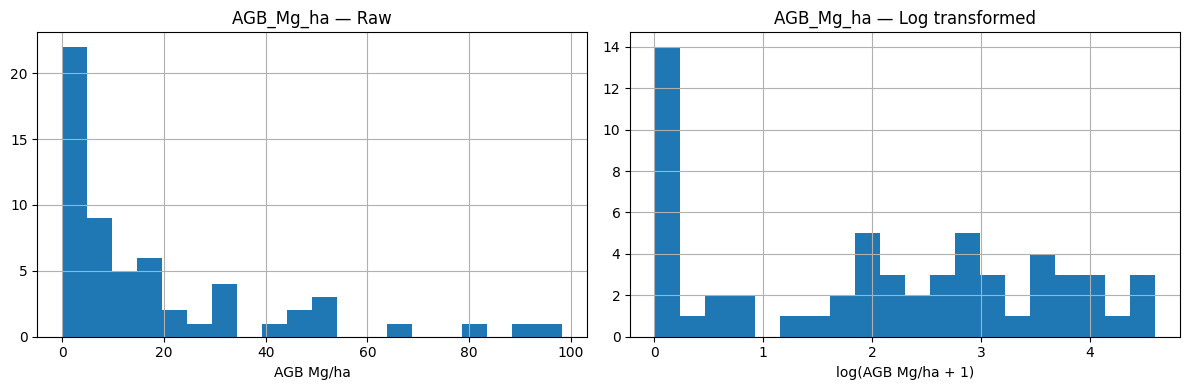

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df['AGB_Mg_ha'].hist(bins=20, ax=axes[0])
axes[0].set_title('AGB_Mg_ha — Raw')
axes[0].set_xlabel('AGB Mg/ha')

import numpy as np
np.log1p(plot_df['AGB_Mg_ha']).hist(bins=20, ax=axes[1])
axes[1].set_title('AGB_Mg_ha — Log transformed')
axes[1].set_xlabel('log(AGB Mg/ha + 1)')

plt.tight_layout()
plt.show()

## DATA PREPROCESSING

### Select feature columns

In [10]:
non_feature_cols = [
    'latitude',            # coordinate
    'longitude',           # coordinate
    'plot_id'
]

targets = ['AGB_Mg_ha', 'total_AGB_kg']
target = 'total_AGB_kg'

emit_cols  = [c for c in plot_df.columns if c.startswith('EMIT')]
emit_cols += ['EVI', 'NDVI', 'NBR', 'MSI']

feature_cols = [c for c in plot_df.columns if c not in targets and c not in non_feature_cols]
X = plot_df[feature_cols]
y = plot_df[target]

print(f"Non-EMIT Features : {set(feature_cols) - set(emit_cols)}")
print(f"Rows     : {len(emit_df)}")
assert len(X["height"].head())

Non-EMIT Features : {'n_trees', 'height'}
Rows     : 3880


### Handle NULL data

In [11]:
X = handle_null_columns(X)

Total NULL count           : 348
Rows with at least one NULL: 29
Total rows                 : 59
Percentage                 : 49.2%

NULL count per column in affected rows:
EMIT_R1350    29
EMIT_R1774    29
EMIT_R1327    29
EMIT_R1335    29
EMIT_R1342    29
EMIT_R1357    29
EMIT_R1417    29
EMIT_R1424    29
EMIT_R1432    29
EMIT_R1781    29
EMIT_R1789    29
EMIT_R1796    29
dtype: int64
Dropping 12 columns:
['EMIT_R1327', 'EMIT_R1335', 'EMIT_R1342', 'EMIT_R1350', 'EMIT_R1357', 'EMIT_R1417', 'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774', 'EMIT_R1781', 'EMIT_R1789', 'EMIT_R1796']

NULL count after dropping: 0


### Remove Low Variance Features (cols)

In [12]:
X = remove_low_variance_cols(X,
                             exclude_cols=['height'],
                             debug=False,
                             exclude_categorical=True)
assert X is not None

Total low variance columns removed: 103
Features after variance filtering: 183


### Remove Features With Weak Correlation to Target

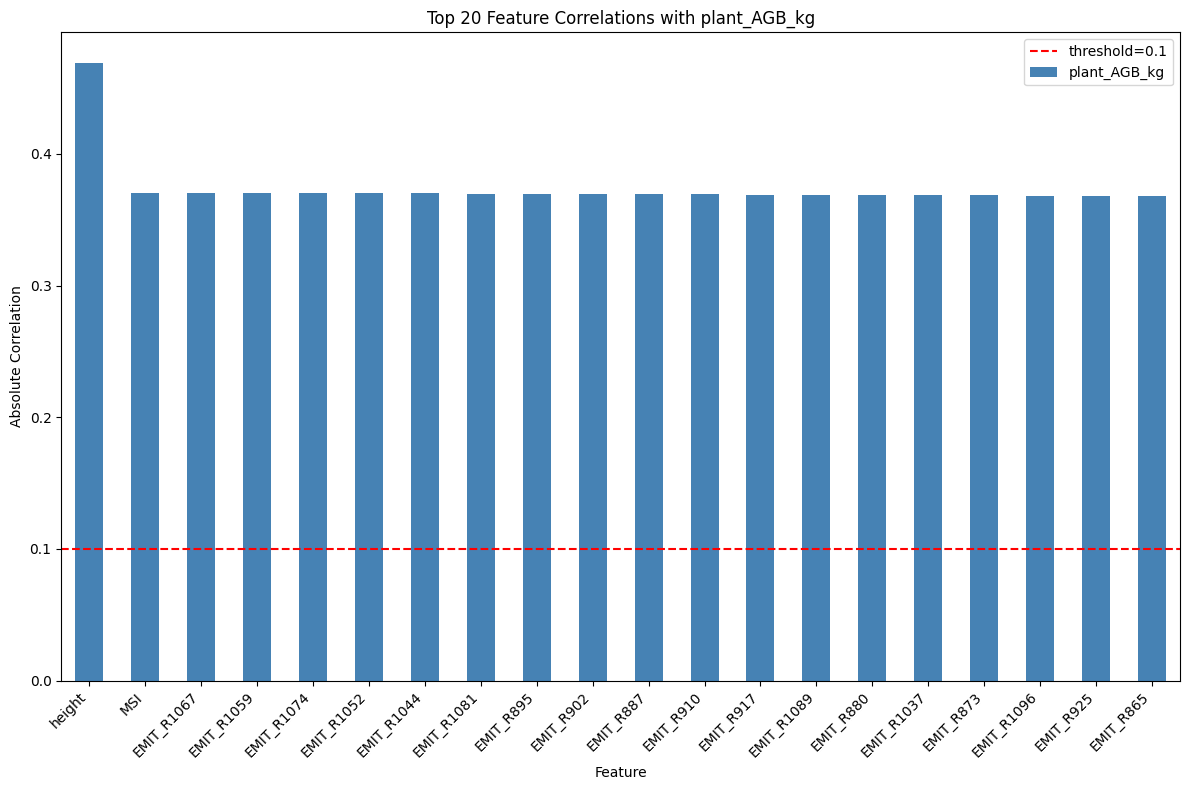

height        0.468914
MSI           0.370694
EMIT_R1067    0.370560
EMIT_R1059    0.370484
EMIT_R1074    0.370306
EMIT_R1052    0.370256
EMIT_R1044    0.370052
EMIT_R1081    0.369552
EMIT_R895     0.369395
EMIT_R902     0.369308
EMIT_R887     0.369245
EMIT_R910     0.369191
EMIT_R917     0.369075
EMIT_R1089    0.369030
EMIT_R880     0.368833
EMIT_R1037    0.368693
EMIT_R873     0.368553
EMIT_R1096    0.368105
EMIT_R925     0.368073
EMIT_R865     0.367850
Name: plant_AGB_kg, dtype: float64


In [13]:
numerical_cols = get_numerical_cols(X)

target_corr = plot_correlation_matrix(X[numerical_cols],
                                      y,
                                      top_n=20)
print(target_corr)

**Remove uncorrelated numerical columns**

In [14]:
X = remove_uncorrelated_numerical_cols(X, y, exclude_cols=['height', 'n_trees'])
assert X is not None

Weak correlations removed: ['NBR', 'EVI', 'EMIT_R2485', 'NDVI']

Total features after correlation filtering: 179


In [15]:
X = remove_uncorrelated_categorical_cols(X, y)
assert X is not None


Empty DataFrame
Columns: []
Index: []


Strong correlations kept   : 179
Weak correlations removed: 0


### Convert categorical variables to one-hot encoding

In [16]:
categorical_cols = get_categorical_cols(X)
print(f"Categorical columns: {categorical_cols}")

if categorical_cols:
    X = pd.get_dummies(X, columns=categorical_cols, dtype=int)

Categorical columns: []


# LINEAR REGRESSION

In [37]:
%run Model_functions.ipynb

In [38]:
linear_reg_experiments = {}

In [39]:
label_1 = "Structural variables"

other_cols = [c for c in X.columns if c not in emit_cols]
data = X[other_cols]

#print(f"CV=5, Features: {other_cols}, Rows: {len(data)}")
results = linear_reg_regular(data, y, 5, label_1)
results["X_data"] = data.copy()
results["Features"] = other_cols

linear_reg_experiments["LIN: " + label_1] = results


 LINEAR REGRESSIONStructural variables ---
Test R²     : 0.6073
Test RMSE   : 113.81 kg
Train R² (log scale): 0.2596
Train R² (orig scale): -14.2279
Train RMSE  : 1498.67 kg
Num Features: 2

 Cross-validation ---
CV R² mean: -0.2184
CV R² std : 0.3991
CV scores : [ 0.185 -0.612 -0.676 -0.286  0.297]


In [40]:
label_2 = "All variables (Structural + EMIT)"

data = X[X.columns]

#print(f"CV=5, Features: {other_cols}, Rows: {len(data)}")
results = linear_reg_regular(data, y, 5, label_2)
results["X_data"] = data.copy()
results["Features"] = other_cols

linear_reg_experiments["LIN: " + label_2] = results


 LINEAR REGRESSIONAll variables (Structural + EMIT) ---
Test R²     : -0.1981
Test RMSE   : 198.78 kg
Train R² (log scale): 0.9785
Train R² (orig scale): 0.9191
Train RMSE  : 109.24 kg
Num Features: 179

 Cross-validation ---
CV R² mean: 0.4192
CV R² std : 0.4264
CV scores : [-0.37   0.473  0.506  0.562  0.924]


### Residual analysis

# RANDOM FOREST.

In [48]:
%run Model_functions.ipynb

In [49]:
random_forest_experiments={}

In [50]:
#label_1 = "Structural variables without plot_id"

data = linear_reg_experiments["LIN: " + label_1]["X_data"]
features = linear_reg_experiments["LIN: " + label_1]["Features"]

#print(f"Features: {features}, Rows: {len(data)}")
results = randomForest_regular(data,
                               y,
                               5,
                               label_1)
results["X_data"] = data.copy()
random_forest_experiments["RF: " +label_1] = results

show_importances(results)


 LINEAR REGRESSIONStructural variables ---
Test R²     : 0.7597
Test RMSE   : 89.03 kg
Train R² (log scale): 0.9101
Train R² (orig scale): 0.4636
Train RMSE  : 281.26 kg
Num Features: 2

 Cross-validation ---
CV R² mean: 0.7136
CV R² std : 0.1196
CV scores : [0.676 0.511 0.722 0.796 0.863]

Top 4 feature importances:
  height                                        0.7812  ███████████████████████████████████████
  n_trees                                       0.2188  ██████████


In [ ]:
label_2 = "All variables (Structural + EMIT)"

data     = linear_reg_experiments["LIN: " + label_2]["X_data"]
features = linear_reg_experiments["LIN: " + label_2]["Features"]

#print(f"Features: {features}, Rows: {len(data)}")
results = randomForest_regular(data,
                               y,
                               5,
                               label_2)
results["X_data"] = data.copy()
random_forest_experiments["RF: " + label_2] = results

show_importances(results)


 LINEAR REGRESSIONAll variables (Structural + EMIT) ---
Test R²     : 0.8962
Test RMSE   : 58.52 kg
Train R² (log scale): 0.9556
Train R² (orig scale): 0.8281
Train RMSE  : 159.24 kg
Num Features: 179


### ANALYSIS
CV mean  : 0.71, std 0.12 — consistent and reliable across folds  
Test R²  : 0.76 aligns well with CV mean — model generalizes well  
Train R² : 0.46 < Test R² 0.76 is still a bit unusual but not alarming given small sample size